# MongoDB Query Benchmark

Each query is written out plainly as `db.collection.find(...)` /
`db.collection.aggregate(...)` and wrapped in `bench(...)`, which records its
**execution time**.

Per query:
- **`wall_ms_median`** — end-to-end wall-clock ms to run the query and fully
  materialize the results, median of `REPEATS` runs (after `WARMUP` warmups).
  This is the number to compare against an equivalent relational query.
- **`server_ms`** — server-side `executionTimeMillis` from `.explain()`
  (captured for `find` queries; `None` for aggregates).

Run the setup cells once, then run each query cell. Re-running a query cell
just updates its row (keyed by name), so timings never duplicate.

In [25]:
import os, time
from statistics import median
import pandas as pd
from pymongo import MongoClient

MONGO_URI = os.getenv("MONGO_URI", "mongodb://localhost:27017")
MONGO_DB  = os.getenv("MONGO_DB", "yelp")
REPEATS   = 5      # timed runs per query (median is reported)
WARMUP    = 1      # throwaway runs before timing (warms cache)

client = MongoClient(MONGO_URI)
db = client[MONGO_DB]
print("Connected:", MONGO_URI, "| db =", MONGO_DB)

Connected: mongodb://localhost:27017 | db = yelp


## Context — server, collection sizes, sample keys\n\nPicks real `BID` / `UID` / `CITY` values from the data so the queries below are meaningful. Uses these variables directly inside the queries.

In [26]:
print("server version:", client.server_info()["version"])
for c in ["businesses", "users", "reviews", "tips"]:
    print(f"  {c:12s}: {db[c].estimated_document_count():,}")

_b = db.businesses.find_one(sort=[("review_count", -1)], projection={"id": 1})
BID = _b["id"] if _b else None

_u = (db.users.find_one({"reviews_preview.0": {"$exists": True}}, projection={"id": 1})
      or db.users.find_one(projection={"id": 1}))
UID = _u["id"] if _u else None

_c = list(db.businesses.aggregate([
    {"$group": {"_id": "$city", "n": {"$sum": 1}}},
    {"$sort": {"n": -1}}, {"$limit": 1}]))
CITY = _c[0]["_id"] if _c else None

print("\nsample BID :", BID)
print("sample UID :", UID)
print("sample CITY:", CITY)

server version: 8.3.8
  businesses  : 150,346
  users       : 1,000,000
  reviews     : 1,999,994
  tips        : 754,776

sample BID : VQcCL9PiNL_wkGf-uF3fjg
sample UID : qVc8ODYU5SZjKXVBgXdI7w
sample CITY: None


## The timer\n\n`bench(name, fn)` runs `fn()` (a lambda returning a cursor) `REPEATS` times and stores the median. Write the actual query in the lambda.

In [27]:
results = []

def bench(name, fn, repeats=REPEATS, warmup=WARMUP):
    for _ in range(warmup):
        list(fn())
    times, n = [], 0
    for _ in range(repeats):
        t0 = time.perf_counter()
        rows = list(fn())
        times.append((time.perf_counter() - t0) * 1000.0)
        n = len(rows)
    wall = median(times)

    results[:] = [r for r in results if r["name"] != name]   # idempotent re-runs
    results.append({"db": "mongodb", "name": name,
                    "wall_ms_median": round(wall, 2),
                    "n_returned": n})
    print(f"{name:30s}  wall={wall:8.2f} ms  n={n}")

## Queries One query per cell, written literally. Run them in any order.

**1. Business profile — point read by `id`**

In [28]:
bench("business_profile_by_id",
      lambda: db.businesses.find({"id": BID}))

business_profile_by_id          wall=    2.81 ms  n=1


**2. Geo — open businesses within 2 km of a point** (uses the `2dsphere` index)

In [29]:
bench("geo_near_2km_open",
      lambda: db.businesses.find({
          "is_open": 1,
          "location.geo": {"$near": {
              "$geometry": {"type": "Point", "coordinates": [-90.335, 38.551]},
              "$maxDistance": 2000}}
      }))

geo_near_2km_open               wall=   20.82 ms  n=80


**3. Top-rated restaurants in a city** (filter + sort)

In [30]:
bench("top_restaurants_in_city",
      lambda: db.businesses.find(
          {"city": CITY, "categories": "Restaurants", "review_count": {"$gte": 50}},
          {"name": 1, "stars": 1, "review_count": 1}
      ).sort([("stars", -1), ("review_count", -1)]).limit(20))

top_restaurants_in_city         wall=  431.84 ms  n=20


**4. Attribute filter — dog-friendly + takes reservations**

In [31]:
bench("attribute_filter",
      lambda: db.businesses.find(
          {"attributes.DogsAllowed": "True",
           "attributes.RestaurantsReservations": "True"},
          {"name": 1, "city": 1}
      ))

attribute_filter                wall=  395.21 ms  n=1151


**5. Find all reviews per business id**

In [32]:
bench("all_reviews_for_business",
      lambda: db.reviews.find({"business_id": BID}))

all_reviews_for_business        wall=   59.99 ms  n=4706


**6. Monthly review trend for one business** (aggregate group over dates)

In [33]:
bench("review_monthly_trend",
      lambda: db.reviews.aggregate([
          {"$match": {"business_id": BID}},
          {"$group": {"_id": {"y": {"$year": "$date"}, "m": {"$month": "$date"}},
                       "n": {"$sum": 1}}},
          {"$sort": {"_id.y": 1, "_id.m": 1}}]))

review_monthly_trend            wall=   28.83 ms  n=149


**7. Most-connected users** (filter + sort on a scalar count)

In [39]:
bench("top_users_by_friends",
      lambda: db.users.find({}, {"name": 1, "friend_count": 1})
                      .sort([("friend_count", -1)]).limit(10))

top_users_by_friends            wall= 1617.59 ms  n=10


**8. Total check-ins by city** (aggregate group over `checkin_stats`)

In [35]:
bench("checkins_by_city",
      lambda: db.businesses.aggregate([
          {"$group": {"_id": "$city", "checkins": {"$sum": "$checkin_stats.total"}}},
          {"$sort": {"checkins": -1}}]))

checkins_by_city                wall=  339.64 ms  n=1


**9. Average stars by category** (aggregate unwind + group)

In [36]:
bench("category_avg_stars",
      lambda: db.businesses.aggregate([
          {"$unwind": "$categories"},
          {"$group": {"_id": "$categories", "avg_stars": {"$avg": "$stars"},
                       "n": {"$sum": 1}}},
          {"$match": {"n": {"$gte": 50}}},
          {"$sort": {"avg_stars": -1}}]))

category_avg_stars              wall= 1253.74 ms  n=718


**10. Reviews per business — top 10** (heavy group over the whole collection)

In [37]:
bench("reviews_per_business_top10",
      lambda: db.reviews.aggregate([
          {"$group": {"_id": "$business_id", "n": {"$sum": 1}}},
          {"$sort": {"n": -1}}, {"$limit": 10}]))

reviews_per_business_top10      wall= 2473.57 ms  n=10


## Results — table, CSV, chart

saved -> data/benchmarks/mongo_query_times.csv


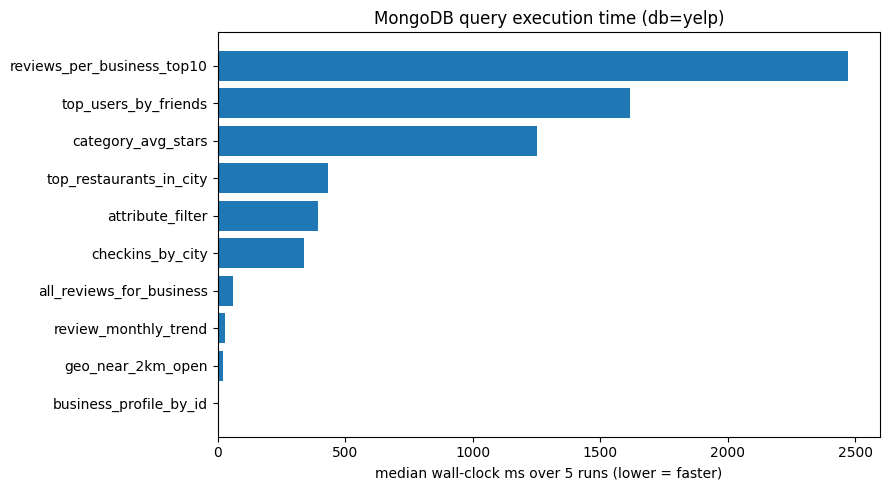

,db,name,wall_ms_median,n_returned
0,mongodb,business_profile_by_id,2.81,1
1,mongodb,geo_near_2km_open,20.82,80
2,mongodb,top_restaurants_in_city,431.84,20
3,mongodb,attribute_filter,395.21,1151
4,mongodb,all_reviews_for_business,59.99,4706
5,mongodb,review_monthly_trend,28.83,149
6,mongodb,checkins_by_city,339.64,1
7,mongodb,category_avg_stars,1253.74,718
8,mongodb,reviews_per_business_top10,2473.57,10
9,mongodb,top_users_by_friends,1617.59,10


In [40]:
results_df = pd.DataFrame(results)
os.makedirs("data/benchmarks", exist_ok=True)
results_df.to_csv("data/benchmarks/mongo_query_times.csv", index=False)
print("saved -> data/benchmarks/mongo_query_times.csv")

try:
    import matplotlib.pyplot as plt
    d = results_df.dropna(subset=["wall_ms_median"]).sort_values("wall_ms_median")
    plt.figure(figsize=(9, 5))
    plt.barh(d["name"], d["wall_ms_median"])
    plt.xlabel(f"median wall-clock ms over {REPEATS} runs (lower = faster)")
    plt.title(f"MongoDB query execution time (db={MONGO_DB})")
    plt.tight_layout()
    plt.savefig("data/benchmarks/mongo_query_times.png", dpi=120)
    plt.show()
except Exception as e:
    print("plot skipped:", e)

results_df